In [2]:
# Notebook 3: AI Object Detection
# You'll learn: how a pretrained model finds objects in an image.

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

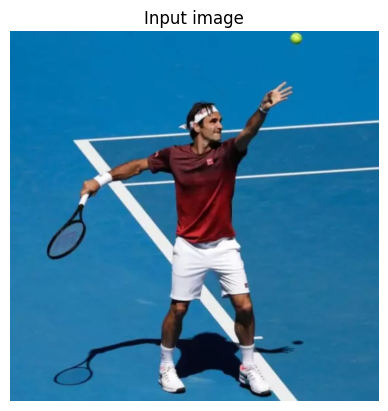

In [10]:
# Load an image
img = cv2.imread("../images/captured_image.png")

if img is None:
    raise FileNotFoundError("Image not found. Please check the path and try again.")

# Convert BGR to RGB for display
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Display the image
plt.imshow(rgb)
plt.title("Input image")
plt.axis("off")
plt.show()

In [11]:
# Load a pretrained YOLO model
# This model already knows many everyday objects
model = YOLO("yolov8n.pt")

In [12]:
# Run object detection on the image
results = model(img)


0: 640x640 1 person, 1 sports ball, 2 tennis rackets, 292.6ms
Speed: 2.4ms preprocess, 292.6ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


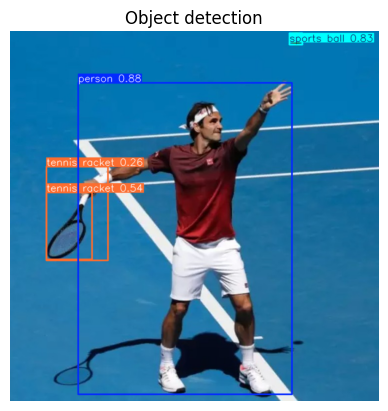

In [13]:
# Draw the predicted boxes and labels on the image
annotated = results[0].plot()

# Convert BGR to RGB for display
annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

plt.imshow(annotated)
plt.title("Object detection")
plt.axis("off")
plt.show()

In [14]:
# Print the detected objects and their confidence scores
for box in results[0].boxes:
    cls_id = int(box.cls[0])
    conf = float(box.conf[0])

    print(model.names[cls_id], round(conf, 2))

person 0.88
sports ball 0.83
tennis racket 0.54
tennis racket 0.26


In [9]:
# ============================================
# 📹 Live face detection
# Goal:
# Detect faces in the camera feed and display them
# ============================================

import cv2
import mediapipe as mp
import time

# --- Parameters ---
CAMERA_INDEX = 0
DISPLAY_SECONDS = 15
WINDOW_NAME = "Live Face Detection"
MODEL_SELECTION = 0                 # 0 = close faces, 1 = far faces
MIN_DETECTION_CONFIDENCE = 0.5
DRAW_DETECTIONS = True              # Toggle drawing on/off

# MediaPipe setup
mp_face_detection = mp.solutions.face_detection
mp_drawing = mp.solutions.drawing_utils

cap = cv2.VideoCapture(CAMERA_INDEX)

if not cap.isOpened():
    print("Could not open camera.")
else:
    start_time = time.time()

    with mp_face_detection.FaceDetection(
        model_selection=MODEL_SELECTION,
        min_detection_confidence=MIN_DETECTION_CONFIDENCE
    ) as face_detection:

        try:
            while True:
                ret, frame = cap.read()
                if not ret:
                    break

                # Convert BGR → RGB
                rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

                # Run detection
                results = face_detection.process(rgb)

                # Draw detections
                if DRAW_DETECTIONS and results.detections:
                    for detection in results.detections:
                        mp_drawing.draw_detection(frame, detection)

                # Display
                cv2.imshow(WINDOW_NAME, frame)

                # Stop after N seconds
                if time.time() - start_time > DISPLAY_SECONDS:
                    break

                # Optional manual quit
                if cv2.waitKey(1) & 0xFF == ord("q"):
                    break

        finally:
            cap.release()
            cv2.waitKey(1)
            cv2.destroyAllWindows()
            cv2.waitKey(1)

I0000 00:00:1773957196.380337 2715417 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 76.3), renderer: Apple M1 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1773957196.411212 2795452 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
